# Monte Carlo radiation transport with variance reduction

This project studies particle transmission through a **1D homogeneous slab** with forward delta scattering. The model is deliberately simple enough to admit an exact analytical solution, which makes it useful for testing Monte Carlo estimators rather than merely producing numerical output.

### What this notebook demonstrates

- an analog Monte Carlo transport estimator;
- dilution biasing with an exact likelihood-ratio correction;
- a closed-form expression for the biased-estimator variance;
- an analytical optimum for the biasing parameter;
- repeated-run validation of the Monte Carlo variance; and
- the tradeoff between statistical variance and computational cost.

The main result is not a grid-search optimum. The optimum can be derived analytically and the simulation is used to **validate that prediction**.

## 1. Model and exact transmission

For a slab of thickness $L$,

$$
\sigma_t=\sigma_s+\sigma_a,
$$

where $\sigma_t$, $\sigma_s$, and $\sigma_a$ are the total, scattering, and absorption macroscopic cross sections.

Because scattering is perfectly forward, it does not change the particle trajectory. A particle is transmitted if it crosses the slab before an absorption event occurs, giving

$$
\boxed{T=e^{-\sigma_aL}}.
$$

This exact result provides the reference value for every Monte Carlo comparison below.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

from src.shielding_mc import (
    ShieldingModel,
    analog_tally_variance,
    analytical_transmission,
    biased_tally_variance,
    optimal_delta,
    simulate_analog,
    simulate_biased,
)

MODEL = ShieldingModel(
    thickness=100.0,  # cm
    sigma_t=0.10,     # cm^-1
    sigma_s=0.05,     # cm^-1
    sigma_a=0.05,     # cm^-1
)

N_VALIDATION = 100_000
N_REPLICATE = 50_000
N_REPLICATES = 20
DELTAS = np.round(np.arange(0.50, 1.001, 0.05), 2)

T_EXACT = analytical_transmission(MODEL)
DELTA_OPT = optimal_delta(MODEL)
VAR_ANALOG = analog_tally_variance(MODEL)
VAR_OPT = biased_tally_variance(MODEL, DELTA_OPT)
VAR_REDUCTION = VAR_ANALOG / VAR_OPT

print(f"Exact transmission: {T_EXACT:.8f}")
print(f"Analytical optimum delta: {DELTA_OPT:.6f}")
print(f"Theoretical variance-reduction factor at optimum: {VAR_REDUCTION:.3f}x")

Exact transmission: 0.00673795
Analytical optimum delta: 0.707107
Theoretical variance-reduction factor at optimum: 2.380x


## 2. Biasing estimator and analytical variance

All macroscopic cross sections are diluted by the same factor,

$$
\tilde\sigma_j=\delta\sigma_j,\qquad 0<\delta\le1.
$$

Thus $\delta=1$ is exactly the analog process, while smaller values increase the sampled free path. Since every cross section is scaled equally, collision-type probabilities remain unchanged.

For a transmitted history with $n$ scattering collisions, the likelihood ratio between the analog and biased path densities is

$$
Q_n=\delta^{-n}\exp\left[(\delta-1)\sigma_tL\right].
$$

Absorbed histories contribute zero. Summing over all possible transmitted histories gives

$$
E_b[Q]=e^{-\sigma_aL}=T,
$$

so the estimator is unbiased. Its exact second moment is

$$
E_b[Q^2]=
\exp\left\{L\left[(\delta-2)\sigma_t+\frac{\sigma_s}{\delta}\right]\right\},
$$

and therefore

$$
\boxed{
\operatorname{Var}_b(Q)=
\exp\left\{L\left[(\delta-2)\sigma_t+\frac{\sigma_s}{\delta}\right]\right\}-T^2
}.
$$

Differentiating the exponent yields the continuous variance-minimizing factor

$$
\boxed{\delta_{\mathrm{opt}}=\sqrt{\frac{\sigma_s}{\sigma_t}}}.
$$

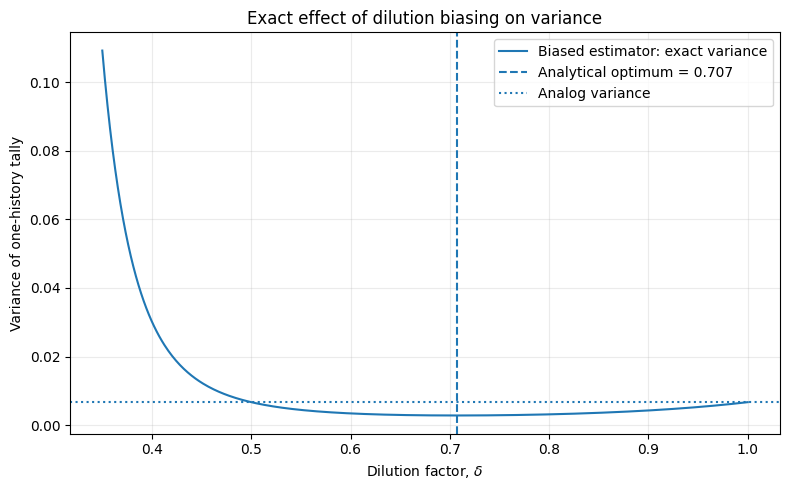

In [2]:
delta_dense = np.linspace(0.35, 1.0, 500)
variance_theory = np.array([biased_tally_variance(MODEL, d) for d in delta_dense])

plt.figure(figsize=(8, 5))
plt.plot(delta_dense, variance_theory, label="Biased estimator: exact variance")
plt.axvline(DELTA_OPT, linestyle="--", label=f"Analytical optimum = {DELTA_OPT:.3f}")
plt.axhline(VAR_ANALOG, linestyle=":", label="Analog variance")
plt.xlabel("Dilution factor, $\\delta$")
plt.ylabel("Variance of one-history tally")
plt.title("Exact effect of dilution biasing on variance")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "theoretical_variance.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Implementation checks

Before benchmarking the method, two checks guard against implementation errors:

1. both estimators must agree statistically with the exact transmission;
2. with the same random-number stream, $\delta=1$ must reproduce the analog tally **history by history**.

The second check is particularly strong because it verifies that the biased transport routine reduces to the analog algorithm, not merely that their final means happen to be similar.

In [3]:
analog_validation = simulate_analog(MODEL, N_VALIDATION, seed=1234)
biased_validation = simulate_biased(MODEL, N_VALIDATION, delta=DELTA_OPT, seed=4321)

analog_same_stream = simulate_analog(MODEL, 20_000, seed=77)
biased_delta_one = simulate_biased(MODEL, 20_000, delta=1.0, seed=77)
np.testing.assert_array_equal(analog_same_stream.tallies, biased_delta_one.tallies)

validation = pd.DataFrame([
    {
        "estimator": "Analog",
        "delta": np.nan,
        "estimate": analog_validation.estimate,
        "standard_error": analog_validation.standard_error,
        "difference_from_exact": analog_validation.estimate - T_EXACT,
    },
    {
        "estimator": "Biased at analytical optimum",
        "delta": DELTA_OPT,
        "estimate": biased_validation.estimate,
        "standard_error": biased_validation.standard_error,
        "difference_from_exact": biased_validation.estimate - T_EXACT,
    },
])

print("delta = 1 check passed: analog and biased tallies are identical history by history.\n")
validation

delta = 1 check passed: analog and biased tallies are identical history by history.



,estimator,delta,estimate,standard_error,difference_from_exact
0,Analog,NaN,0.006460,0.000253,-0.000278
1,Biased at analytical optimum,0.707107,0.006667,0.000161,-0.000071


## 4. Repeated Monte Carlo experiment

A single noisy sweep is not a reliable way to identify an optimum. Each configuration is therefore run with independent seeds and summarized across replicates.

For each $\delta$ the analysis records the mean estimate, the between-run spread, the mean one-history sample variance, and the median CPU time. The exact variance remains the reference; the repeated Monte Carlo experiment tests whether the simulation recovers its trend.

The grid is intentionally coarse and focuses on $0.50\le\delta\le1.00$, where the repeated experiment can resolve the second moment with a moderate number of histories. More aggressive dilution remains visible in the analytical curve, but is excluded from the timing benchmark because rare high-weight histories would require much larger samples for a stable empirical variance. The grid is used to verify the analytical optimum, not to replace it.

In [4]:
def collect_replicates(n_histories, deltas, n_replicates, base_seed=10_000):
    rows = []

    for replicate in range(n_replicates):
        analog_result = simulate_analog(
            MODEL,
            n_histories,
            seed=base_seed + 10_000 * replicate,
        )
        rows.append({
            "algorithm": "analog",
            "delta": np.nan,
            "replicate": replicate,
            "estimate": analog_result.estimate,
            "reported_se": analog_result.standard_error,
            "tally_variance": analog_result.tally_variance,
            "cpu_time": analog_result.elapsed_cpu,
        })

        for j, delta in enumerate(deltas, start=1):
            result = simulate_biased(
                MODEL,
                n_histories,
                delta=float(delta),
                seed=base_seed + 10_000 * replicate + j,
            )
            rows.append({
                "algorithm": "biased",
                "delta": float(delta),
                "replicate": replicate,
                "estimate": result.estimate,
                "reported_se": result.standard_error,
                "tally_variance": result.tally_variance,
                "cpu_time": result.elapsed_cpu,
            })

    return pd.DataFrame(rows)


def summarize_replicates(df, n_histories):
    summaries = []

    analog_group = df[df["algorithm"] == "analog"]
    groups = [("analog", np.nan, analog_group)]
    groups.extend(
        ("biased", float(delta), group)
        for delta, group in df[df["algorithm"] == "biased"].groupby("delta")
    )

    for algorithm, delta, group in groups:
        median_cpu_time = group["cpu_time"].median()
        median_cpu_per_history = median_cpu_time / n_histories
        mean_tally_variance = group["tally_variance"].mean()
        theoretical_tally_variance = (
            analog_tally_variance(MODEL)
            if algorithm == "analog"
            else biased_tally_variance(MODEL, delta)
        )

        summaries.append({
            "algorithm": algorithm,
            "delta": delta,
            "mean_estimate": group["estimate"].mean(),
            "bias_vs_exact": group["estimate"].mean() - T_EXACT,
            "between_run_sd": group["estimate"].std(ddof=1),
            "mean_reported_se": group["reported_se"].mean(),
            "mean_tally_variance": mean_tally_variance,
            "theoretical_tally_variance": theoretical_tally_variance,
            "median_cpu_time": median_cpu_time,
            "median_cpu_per_history": median_cpu_per_history,
            "sample_efficiency": 1.0 / (median_cpu_per_history * mean_tally_variance),
            "theory_efficiency": 1.0 / (median_cpu_per_history * theoretical_tally_variance),
        })

    return pd.DataFrame(summaries)


replicates = collect_replicates(N_REPLICATE, DELTAS, N_REPLICATES)
summary = summarize_replicates(replicates, N_REPLICATE)
biased_summary = summary[summary["algorithm"] == "biased"].sort_values("delta").copy()
analog_summary = summary[summary["algorithm"] == "analog"].iloc[0]

### 4.1 Core statistical result: theory versus simulation

If the implementation is correct, the empirical tally variance should follow the exact curve and the best grid point should land close to $\delta_{\mathrm{opt}}$.

Aggressive dilution can create rare, high-weight transmitted histories. That regime is visible in the exact curve above but is not used in the repeated benchmark, because a modest finite sample can substantially underestimate its second moment. This is also why the exact variance is the validation reference rather than a noisy sweep alone.

Continuous analytical optimum: 0.707107
Best grid point by exact variance: 0.70
Best grid point by repeated-run sample variance: 0.70


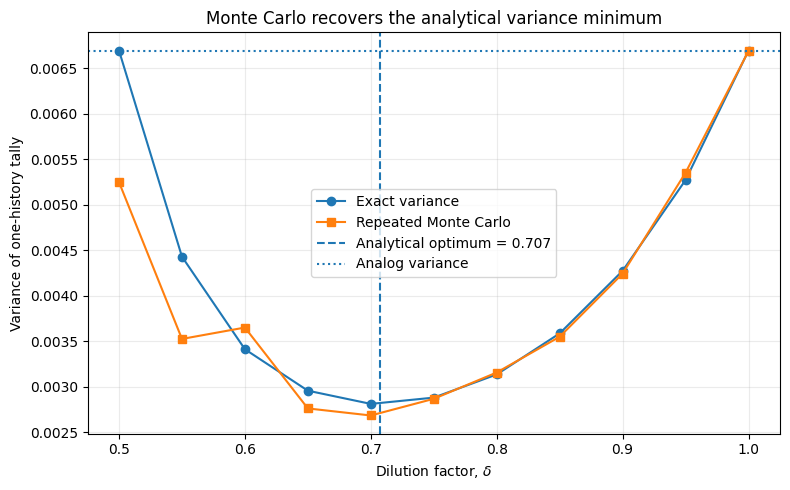

In [5]:
best_theory_grid = biased_summary.loc[biased_summary["theoretical_tally_variance"].idxmin()]
best_sample_grid = biased_summary.loc[biased_summary["mean_tally_variance"].idxmin()]

print(f"Continuous analytical optimum: {DELTA_OPT:.6f}")
print(f"Best grid point by exact variance: {best_theory_grid['delta']:.2f}")
print(f"Best grid point by repeated-run sample variance: {best_sample_grid['delta']:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(
    biased_summary["delta"],
    biased_summary["theoretical_tally_variance"],
    marker="o",
    label="Exact variance",
)
plt.plot(
    biased_summary["delta"],
    biased_summary["mean_tally_variance"],
    marker="s",
    label="Repeated Monte Carlo",
)
plt.axvline(DELTA_OPT, linestyle="--", label=f"Analytical optimum = {DELTA_OPT:.3f}")
plt.axhline(VAR_ANALOG, linestyle=":", label="Analog variance")
plt.xlabel("Dilution factor, $\\delta$")
plt.ylabel("Variance of one-history tally")
plt.title("Monte Carlo recovers the analytical variance minimum")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "variance_validation.png", dpi=160, bbox_inches="tight")
plt.show()

### 4.2 Mean estimates across independent runs

Unbiasedness is not established by asking whether one realization lies inside a one-standard-error interval. A more useful diagnostic is whether repeated estimates remain centered on the exact solution while their observed spread is consistent with the uncertainty reported by the estimator.

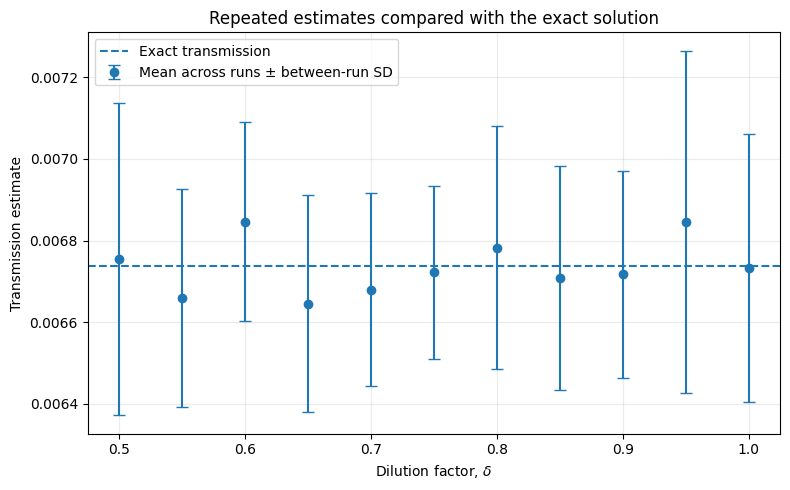

,delta,mean_estimate,bias_vs_exact,between_run_sd,mean_reported_se
1,0.50,0.006754,0.000016,0.000383,0.000312
2,0.55,0.006660,-0.000078,0.000267,0.000262
3,0.60,0.006846,0.000108,0.000244,0.000268
4,0.65,0.006646,-0.000092,0.000265,0.000234
5,0.70,0.006679,-0.000059,0.000237,0.000231
6,0.75,0.006722,-0.000016,0.000212,0.000239
7,0.80,0.006783,0.000045,0.000298,0.000251
8,0.85,0.006708,-0.000030,0.000275,0.000266
9,0.90,0.006718,-0.000020,0.000254,0.000291
10,0.95,0.006845,0.000108,0.000420,0.000327


In [6]:
comparison = biased_summary[[
    "delta",
    "mean_estimate",
    "bias_vs_exact",
    "between_run_sd",
    "mean_reported_se",
]].copy()

plt.figure(figsize=(8, 5))
plt.errorbar(
    comparison["delta"],
    comparison["mean_estimate"],
    yerr=comparison["between_run_sd"],
    fmt="o",
    capsize=4,
    label="Mean across runs ± between-run SD",
)
plt.axhline(T_EXACT, linestyle="--", label="Exact transmission")
plt.xlabel("Dilution factor, $\\delta$")
plt.ylabel("Transmission estimate")
plt.title("Repeated estimates compared with the exact solution")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "unbiasedness_check.png", dpi=160, bbox_inches="tight")
plt.show()

comparison

## 5. Computational efficiency

Variance reduction is only useful if the statistical gain is worth the computational cost. Using CPU time per history, define

$$
\lambda=\frac{1}{t_h\,\operatorname{Var}(Q)}.
$$

Two efficiency estimates are compared below. The sample-based estimate uses the empirical tally variance, while the theory-based estimate uses the exact variance together with the measured median CPU time. The latter is less sensitive to Monte Carlo noise in the second moment.

Timing remains implementation- and machine-dependent, so the efficiency-maximizing $\delta$ is a computational result, not a universal physical constant.

Best grid point by theory-based efficiency: 0.70
Best grid point by sample-based efficiency: 0.70


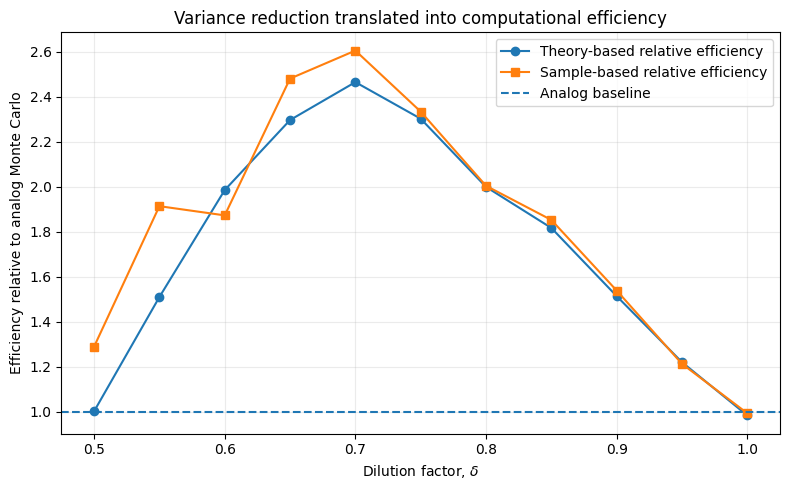

In [7]:
biased_summary["relative_efficiency_theory"] = (
    biased_summary["theory_efficiency"] / analog_summary["theory_efficiency"]
)
biased_summary["relative_efficiency_sample"] = (
    biased_summary["sample_efficiency"] / analog_summary["sample_efficiency"]
)

best_eff_theory = biased_summary.loc[biased_summary["theory_efficiency"].idxmax()]
best_eff_sample = biased_summary.loc[biased_summary["sample_efficiency"].idxmax()]

print(f"Best grid point by theory-based efficiency: {best_eff_theory['delta']:.2f}")
print(f"Best grid point by sample-based efficiency: {best_eff_sample['delta']:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(
    biased_summary["delta"],
    biased_summary["relative_efficiency_theory"],
    marker="o",
    label="Theory-based relative efficiency",
)
plt.plot(
    biased_summary["delta"],
    biased_summary["relative_efficiency_sample"],
    marker="s",
    label="Sample-based relative efficiency",
)
plt.axhline(1.0, linestyle="--", label="Analog baseline")
plt.xlabel("Dilution factor, $\\delta$")
plt.ylabel("Efficiency relative to analog Monte Carlo")
plt.title("Variance reduction translated into computational efficiency")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "relative_efficiency.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Compact result summary

The table below focuses the summary on the analog baseline and the grid point closest to the analytical optimum. Detailed per-$\delta$ results remain available in the `summary` dataframe for inspection.

In [8]:
nearest_grid_index = (biased_summary["delta"] - DELTA_OPT).abs().idxmin()
near_opt = biased_summary.loc[nearest_grid_index]

portfolio_summary = pd.DataFrame([
    {
        "estimator": "Analog",
        "delta": 1.0,
        "mean estimate": analog_summary["mean_estimate"],
        "exact tally variance": analog_summary["theoretical_tally_variance"],
        "median CPU/history": analog_summary["median_cpu_per_history"],
        "relative efficiency": 1.0,
    },
    {
        "estimator": "Dilution biasing",
        "delta": near_opt["delta"],
        "mean estimate": near_opt["mean_estimate"],
        "exact tally variance": near_opt["theoretical_tally_variance"],
        "median CPU/history": near_opt["median_cpu_per_history"],
        "relative efficiency": near_opt["relative_efficiency_theory"],
    },
])

portfolio_summary

,estimator,delta,mean estimate,exact tally variance,median CPU/history,relative efficiency
0,Analog,1.0,0.006800,0.006693,7.636866e-08,1.000000
1,Dilution biasing,0.7,0.006679,0.002814,7.370701e-08,2.464186


## 7. Interpretation and limitations

The important result is methodological: **the simulation reproduces a variance-reduction optimum that was derived independently from the estimator's second moment.** For the parameters used here, the theoretical optimum reduces the one-history tally variance by a factor of about 2.38 relative to analog Monte Carlo.

The project is intentionally a controlled transport problem rather than a general shielding code. It does not include angular scattering, backscattering, energy loss, energy-dependent cross sections, layered materials, or multidimensional geometry. Those extensions would remove much of the analytical convenience used here for validation.

Basic implementation checks such as exponential free-path sampling, cross-section consistency, convergence, and the $\delta=1$ identity are maintained in the automated `tests/` suite rather than occupying the main analytical narrative.